# Datos del alumno

**Nombre**: Lino

**Apellidos**: Bossio

**Grupo:**

# Sprint 2 - Árboles de decisión para explicar la rotación de empleados

El objetivo del proyecto es predecir si un trabajador va a abandonar la empresa o no (variable `left`).

En el sprint 1 se construyó un modelo con buen poder predictivo, pero el cliente -al ser su primer proyecto de
analítica- no acaba de fiarse de unos resultados que no puede interpretar. Por eso en este sprint cambiamos a un
modelo de **caja blanca**: el **árbol de decisión**, que permite leer literalmente las reglas que ha aprendido.

**Contenido del notebook**

| Sección | Contenido |
|---|---|
| 0 | Configuración, carga de datos y recuperación de los nombres de los atributos |
| 1 | **Cuestión 1** - Árbol sin criterio de poda (hiperparámetros por defecto) |
| 2 | **Cuestión 2** - Árbol con la profundidad limitada (`max_depth`) |
| 3 | **Cuestión 3** - Árbol con criterio `entropy` e hiperparámetros optimizados por `GridSearchCV` |
| 3.bis | Árbol extra: poda por coste-complejidad (`ccp_alpha`) |
| 4 | **Cuestión 4** - Comparativa de los árboles y elección justificada del mejor |
| 5 | **Cuestión 5** - Representación visual y literal del mejor árbol e interpretación de sus reglas |
| 6 | Comparación con el mejor modelo del sprint 1 y ventajas de cada enfoque |
| 7 | Conclusiones |

## 0. Configuración del entorno

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve,
                             precision_recall_curve,
                             average_precision_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             classification_report)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     learning_curve,
                                     validation_curve,
                                     train_test_split,
                                     StratifiedKFold)
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

Y las librerías específicas de este sprint (árboles de decisión).

In [2]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

> *Nota sobre `dtreeviz`*: la plantilla propone usar `dtreeviz` para la representación gráfica. Esa librería depende
> de `graphviz` (un binario externo) y no está disponible en el entorno en el que se ha ejecutado este notebook, así
> que la representación visual se hace con `sklearn.tree.plot_tree`, que no requiere dependencias adicionales y
> muestra exactamente la misma información (regla, impureza, reparto de clases y clase mayoritaria por nodo).
> Si se ejecuta en Colab basta con descomentar la celda siguiente para usar también `dtreeviz`.

In [3]:
## Si no habeis instalado previamente la libreria, teneis que descomentar la siguiente linea para descargar dtreeviz
#!pip install dtreeviz
#import dtreeviz

### 0.1 Carga de las matrices de train y test del sprint 1

Reutilizamos las particiones calculadas en el sprint 1 (`X_train.npy`, `X_test.npy`, `y_train.npy`, `y_test.npy`).
La celda busca primero los ficheros en local (por si se ejecuta desde el repositorio) y, si no los encuentra, los
descarga de Google Drive como en la plantilla original.

In [4]:
FICHEROS = ["X_train.npy", "X_test.npy", "y_train.npy", "y_test.npy", "Rotacion_empleados.csv"]

# Rutas candidatas: directorio actual, ./data y la carpeta data_proyecto/data del repositorio
CANDIDATAS = [Path("."), Path("data"), Path("data_proyecto/data"),
              Path("../data_proyecto/data"), Path("../data")]

ENLACES = {
    "y_train.npy":            "1S7DtU2HEFXkqyJp_RcILNSgEsY3huIL9",
    "y_test.npy":             "1O1BRGwSd81TOOpaQvoo5BHDsrPEruz93",
    "X_train.npy":            "1u3yI5L_2YI77uF_WT9ysIzw8dydVlQSh",
    "X_test.npy":             "1eWo_m2gbihSuUQeOhH8I8Q0uudluQKBT",
    "Rotacion_empleados.csv": "1ZwgdmI525zInDh1SQVm7FZt8kWxfrvOK",
}


def localizar(nombre):
    """Devuelve la ruta local del fichero; si no existe, lo descarga de Google Drive."""
    for carpeta in CANDIDATAS:
        ruta = carpeta / nombre
        if ruta.exists():
            return ruta
    url = f"https://drive.google.com/uc?export=download&id={ENLACES[nombre]}"
    os.system(f"wget --no-check-certificate '{url}' -O '{nombre}'")
    return Path(nombre)


RUTAS = {f: localizar(f) for f in FICHEROS}
RUTAS

{'X_train.npy': WindowsPath('../data_proyecto/data/X_train.npy'),
 'X_test.npy': WindowsPath('../data_proyecto/data/X_test.npy'),
 'y_train.npy': WindowsPath('../data_proyecto/data/y_train.npy'),
 'y_test.npy': WindowsPath('../data_proyecto/data/y_test.npy'),
 'Rotacion_empleados.csv': WindowsPath('../data_proyecto/data/Rotacion_empleados.csv')}

Verificamos que las dimensiones se corresponden con la partición de 80% train / 20% test.

In [5]:
X_train = np.load(RUTAS["X_train.npy"])
X_test  = np.load(RUTAS["X_test.npy"])
y_train = np.load(RUTAS["y_train.npy"])
y_test  = np.load(RUTAS["y_test.npy"])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print()
print(f"Proporción train/test: {len(y_train) / (len(y_train) + len(y_test)):.0%} / "
      f"{len(y_test) / (len(y_train) + len(y_test)):.0%}")

X_train: (11999, 17)
X_test : (3000, 17)
y_train: (11999,)
y_test : (3000,)

Proporción train/test: 80% / 20%


### 0.2 El problema está desbalanceado

Antes de entrenar nada conviene recordar el reparto de clases, porque **condiciona qué métricas podemos usar**: con
una clase minoritaria en torno al 24%, un modelo trivial que predijese siempre "no se va" alcanzaria ya un ~76% de
*accuracy* sin haber aprendido absolutamente nada.

              train  test
0 (se queda)   9142  2286
1 (se va)      2857   714

% clase 'se va' en train: 23.81%
% clase 'se va' en test : 23.80%


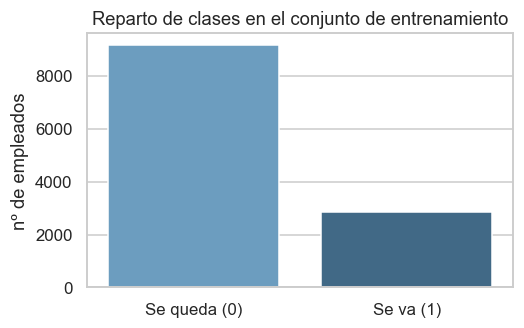

In [6]:
def reparto(y, nombre):
    v, c = np.unique(y, return_counts=True)
    return pd.Series(c, index=[f"{int(i)} ({'se queda' if i == 0 else 'se va'})" for i in v], name=nombre)

balance = pd.concat([reparto(y_train, "train"), reparto(y_test, "test")], axis=1)
print(balance)
print()
print(f"% clase 'se va' en train: {(y_train == 1).mean():.2%}")
print(f"% clase 'se va' en test : {(y_test == 1).mean():.2%}")

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=["Se queda (0)", "Se va (1)"],
            y=[(y_train == 0).sum(), (y_train == 1).sum()], ax=ax, hue=["Se queda (0)", "Se va (1)"],
            palette="Blues_d", legend=False)
ax.set_title("Reparto de clases en el conjunto de entrenamiento")
ax.set_ylabel("nº de empleados")
plt.show()

Por este motivo, a lo largo del notebook:

* Todos los árboles se entrenan con `class_weight="balanced"`, que ajusta automáticamente los pesos de forma
  inversamente proporcional a la frecuencia de cada clase.
* La métrica principal de decisión es el **F1 de la clase positiva** (el empleado que se va), acompañada de
  **recall**, **precisión**, **ROC-AUC** y **PR-AUC** (*average precisión*). La *accuracy* se reporta, pero no se usa
  como criterio de elección.

### 0.3 Recuperación de los nombres de los atributos

Las matrices `.npy` no conservan los nombres de las columnas, y los necesitaremos en la cuestión 5 para poder leer
las reglas del árbol. Reconstruimos el `DataFrame` original aplicando las mismas transformaciones del sprint 1:

1. Renombrar `sales` -> `department`.
2. Recodificar `salary` conservando el orden: `low=0`, `medium=1`, `high=2`.
3. Convertir `department` en variables *dummy* (`drop_first=True`).

In [7]:
df = pd.read_csv(RUTAS["Rotacion_empleados.csv"])
print("Dataset original:", df.shape)
df.head()

Dataset original: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [8]:
df = df.rename(columns={"sales": "department"})
df["salary"] = df["salary"].map({"low": 0, "medium": 1, "high": 2})

X_df = pd.get_dummies(df.drop(columns=["left"]), columns=["department"], drop_first=True).astype(float)
FEATURES = list(X_df.columns)

print(f"{len(FEATURES)} atributos reconstruidos (X_train tiene {X_train.shape[1]} columnas):")
for i, f in enumerate(FEATURES):
    print(f"  {i:2d}. {f}")

17 atributos reconstruidos (X_train tiene 17 columnas):
   0. satisfaction_level
   1. last_evaluation
   2. number_project
   3. average_montly_hours
   4. time_spend_company
   5. Work_accident
   6. promotion_last_5years
   7. salary
   8. department_RandD
   9. department_accounting
  10. department_hr
  11. department_management
  12. department_marketing
  13. department_product_mng
  14. department_sales
  15. department_support
  16. department_technical


Comprobamos que la reconstrucción es correcta: si el orden de las columnas coincide con el usado en el sprint 1, la
distribucion de valores de cada columna del `DataFrame` reconstruido debe ser idéntica a la de la columna homóloga de
`np.vstack([X_train, X_test])`.

In [9]:
X_todo = np.vstack([X_train, X_test])
coinciden = all(np.allclose(np.sort(X_df[c].values), np.sort(X_todo[:, j]))
                for j, c in enumerate(FEATURES))
print("Los nombres de atributos se corresponden con las columnas de X_train/X_test:", coinciden)

Los nombres de atributos se corresponden con las columnas de X_train/X_test: True


### 0.4 Una advertencia sobre los datos: registros duplicados

Antes de interpretar ninguna métrica conviene mirar una propiedad del dataset que condiciona todo lo que viene
después: `Rotacion_empleados.csv` contiene **filas exactamente repetidas**. Como la partición train/test del sprint 1
se hizo sin eliminarlas, parte de los empleados del conjunto de test tienen un gemelo idéntico en el de
entrenamiento.

In [10]:
duplicados_csv = df.duplicated().sum()

filas_train = set(map(tuple, np.column_stack([X_train, y_train])))
solapan = sum(1 for fila in map(tuple, np.column_stack([X_test, y_test])) if fila in filas_train)

print(f"Filas duplicadas en el CSV original : {duplicados_csv} de {len(df)} ({duplicados_csv / len(df):.1%})")
print(f"Filas de test que aparecen idénticas en train: {solapan} de {len(y_test)} ({solapan / len(y_test):.1%})")

Filas duplicadas en el CSV original : 3008 de 14999 (20.1%)
Filas de test que aparecen idénticas en train: 929 de 3000 (31.0%)


Casi un tercio del conjunto de test está literalmente presente en el de entrenamiento. Esto significa que **todas las
métricas de este notebook -y las del sprint 1- están infladas**: cualquier modelo con capacidad de memorizar (un
árbol sin podar, un KNN con `weights='distance'`) acierta esos casos sin haber generalizado nada.

No rehacemos la partición porque el enunciado pide comparar con el sprint 1 sobre los mismos datos, y porque el sesgo
afecta por igual a todos los modelos comparados, de modo que la **comparación relativa sigue siendo válida**. Pero
hay que tenerlo presente al leer los valores absolutos, y lo recogemos en las conclusiones como principal limitación
del estudio.

### 0.5 Función auxiliar de evaluación

Definimos una única función de evaluación para que todos los modelos se midan exactamente con la misma vara.

In [11]:
resultados = []   # una fila por modelo evaluado
MODELOS = {}      # nombre -> estimador entrenado


def puntuaciones(modelo, X):
    """Probabilidad (o distancia al hiperplano) de la clase positiva."""
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]
    return modelo.decision_function(X)


def evaluar(nombre, modelo, t_fit=np.nan, guardar=True, informe=True):
    """Evalúa un modelo ya entrenado sobre test (y sobre train, para detectar sobreajuste)."""
    y_pred = modelo.predict(X_test)
    y_score = puntuaciones(modelo, X_test)

    fila = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "f1_train": f1_score(y_train, modelo.predict(X_train)),
        "t_entren_s": t_fit,
    }
    fila["gap_f1"] = fila["f1_train"] - fila["f1"]

    if informe:
        print(f"===== {nombre} =====")
        print(classification_report(y_test, y_pred,
                                    target_names=["Se queda (0)", "Se va (1)"], digits=4))
        print(f"ROC-AUC: {fila['roc_auc']:.4f}   PR-AUC: {fila['pr_auc']:.4f}   "
              f"F1 train: {fila['f1_train']:.4f}   F1 test: {fila['f1']:.4f}   "
              f"(gap: {fila['gap_f1']:+.4f})")

    if guardar:
        resultados.append(fila)
        MODELOS[nombre] = modelo
    return fila


def matriz_confusion(modelo, nombre, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, modelo.predict(X_test)),
                           display_labels=["Se queda", "Se va"]).plot(ax=ax, cmap="Blues",
                                                                     colorbar=False, values_format="d")
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    return ax

# CUESTIÓN 1 - Árbol con hiperparámetros por defecto

Entrenamos un primer árbol **sin ningún criterio de poda**: sin limitar la profundidad, sin mínimos de muestras por
hoja y con el criterio de impureza por defecto (`gini`). Los únicos parámetros que fijamos son
`class_weight="balanced"` -que no controla el crecimiento del árbol, sino que compensa el desbalanceo de clases- y
`random_state`, para que el resultado sea reproducible.

In [12]:
# Generamos un árbol de decisión para clasificación
clf_tree = tree.DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)

# El parámetro class_weight='balanced' emplea los valores de y para ajustar automáticamente los pesos de forma
# inversamente proporcional a la frecuencia de cada clase en el input
clf_tree

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [13]:
# Entrenamos el modelo con los datos de entrenamiento
t0 = time.time()
clf_tree.fit(X_train, y_train)
t_arbol1 = time.time() - t0

print(f"Tiempo de entrenamiento: {t_arbol1:.3f} s")

Tiempo de entrenamiento: 0.024 s


In [14]:
# Obtenemos las predicciones para el conjunto de test
y_pred_arbol1 = clf_tree.predict(X_test)

print("Primeras 20 predicciones :", y_pred_arbol1[:20].astype(int))
print("Primeros 20 valores reales:", y_test[:20].astype(int))

Primeras 20 predicciones : [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1]
Primeros 20 valores reales: [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1]


In [15]:
# ¿Cuál es la profundidad del árbol entrenado?
print(f"Profundidad del árbol : {clf_tree.get_depth()}")
print(f"Número de hojas       : {clf_tree.get_n_leaves()}")
print(f"Número total de nodos : {clf_tree.tree_.node_count}")

Profundidad del árbol : 21
Número de hojas       : 389
Número total de nodos : 777


===== Árbol 1 - sin poda (por defecto) =====
              precision    recall  f1-score   support

Se queda (0)     0.9947    0.9843    0.9894      2286
   Se va (1)     0.9512    0.9832    0.9669       714

    accuracy                         0.9840      3000
   macro avg     0.9730    0.9837    0.9782      3000
weighted avg     0.9843    0.9840    0.9841      3000

ROC-AUC: 0.9837   PR-AUC: 0.9392   F1 train: 1.0000   F1 test: 0.9669   (gap: +0.0331)


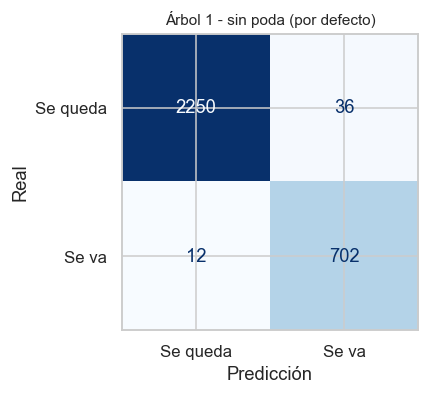

In [16]:
# Evaluar la capacidad predictiva del modelo
ARBOL_1 = "Árbol 1 - sin poda (por defecto)"
evaluar(ARBOL_1, clf_tree, t_arbol1)
matriz_confusion(clf_tree, ARBOL_1)
plt.show()

### Análisis de la cuestión 1

Al dejar crecer el árbol sin restricciones, `scikit-learn` sigue dividiendo hasta que **todas las hojas son puras**.
El resultado es un árbol muy grande -más de veinte niveles y varios cientos de hojas- que **memoriza** el conjunto de
entrenamiento: el F1 en train es exactamente 1.0, mientras que en test baja. Esa diferencia (`gap_f1`) es la firma
del **sobreajuste**.

Dos matices importantes para no sacar conclusiones equivocadas:

* Aun sobreajustado, el rendimiento en test es alto. El dataset es muy "limpio" y la frontera entre quedarse e irse
  está muy marcada por unas pocas variables, así que incluso un árbol enorme generaliza razonablemente bien.
* Un árbol de esta profundidad es **inservible para el objetivo del sprint**: el cliente queria entender los motivos
  de la rotación y nadie puede leer cientos de reglas encadenadas. La caja blanca deja de serlo.

En las cuestiones 2 y 3 comprobamos si podando el árbol ganamos interpretabilidad y estabilidad sin pagar un precio
inaceptable en capacidad predictiva.

# CUESTIÓN 2 - Árbol modificando algún hiperparámetro

*Sugerencia de la plantilla: ¿qué ocurre si limitamos la profundidad del árbol?*

En lugar de elegir un `max_depth` a ojo, lo justificamos con una **curva de validación**: entrenamos árboles de
profundidad creciente y comparamos el F1 en entrenamiento con el F1 de validación cruzada (5 folds). El punto en el
que la curva de validación deja de mejorar mientras la de entrenamiento sigue subiendo marca el inicio del
sobreajuste.

In [17]:
profundidades = list(range(1, 21))

train_scores, cv_scores = validation_curve(
    tree.DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="max_depth", param_range=profundidades,
    cv=5, scoring="f1", n_jobs=-1)

curva = pd.DataFrame({
    "max_depth": profundidades,
    "f1_train": train_scores.mean(axis=1),
    "f1_cv": cv_scores.mean(axis=1),
    "std_cv": cv_scores.std(axis=1),
})
curva["gap"] = curva["f1_train"] - curva["f1_cv"]
curva.round(4)

,max_depth,f1_train,f1_cv,std_cv,gap
0,1,0.6550,0.6548,0.0156,0.0001
1,2,0.7370,0.7370,0.0070,0.0000
2,3,0.8376,0.8376,0.0073,-0.0000
3,4,0.8667,0.8635,0.0080,0.0032
4,5,0.8859,0.8830,0.0097,0.0029
5,6,0.8903,0.8847,0.0043,0.0056
6,7,0.9541,0.9441,0.0064,0.0100
7,8,0.9609,0.9442,0.0092,0.0168
8,9,0.9702,0.9473,0.0093,0.0229
9,10,0.9768,0.9517,0.0091,0.0251


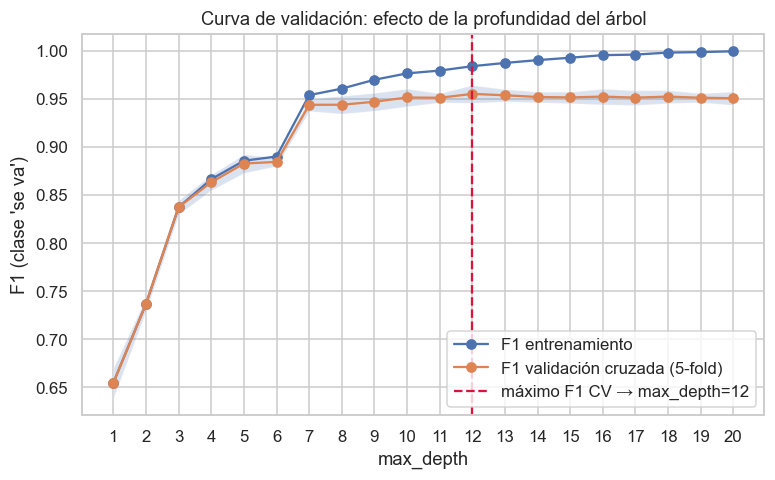

Profundidad con mejor F1 en validación cruzada: 12 (F1 CV = 0.9554)


In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curva["max_depth"], curva["f1_train"], "o-", label="F1 entrenamiento")
ax.plot(curva["max_depth"], curva["f1_cv"], "o-", label="F1 validación cruzada (5-fold)")
ax.fill_between(curva["max_depth"], curva["f1_cv"] - curva["std_cv"],
                curva["f1_cv"] + curva["std_cv"], alpha=0.2)

mejor_depth = int(curva.loc[curva["f1_cv"].idxmax(), "max_depth"])
ax.axvline(mejor_depth, color="crimson", ls="--",
           label=f"máximo F1 CV → max_depth={mejor_depth}")
ax.set_xticks(profundidades)
ax.set_xlabel("max_depth"); ax.set_ylabel("F1 (clase 'se va')")
ax.set_title("Curva de validación: efecto de la profundidad del árbol")
ax.legend()
plt.show()

print(f"Profundidad con mejor F1 en validación cruzada: {mejor_depth} "
      f"(F1 CV = {curva['f1_cv'].max():.4f})")

Entrenamos el **árbol 2** con esa profundidad. Añadimos además `min_samples_leaf=5` para evitar hojas construidas
sobre un puñado de empleados, que son las que peor generalizan.

Profundidad: 12   Hojas: 170   Tiempo: 0.020 s
===== Árbol 2 - max_depth=12, min_samples_leaf=5 =====
              precision    recall  f1-score   support

Se queda (0)     0.9876    0.9777    0.9826      2286
   Se va (1)     0.9308    0.9608    0.9456       714

    accuracy                         0.9737      3000
   macro avg     0.9592    0.9692    0.9641      3000
weighted avg     0.9741    0.9737    0.9738      3000

ROC-AUC: 0.9887   PR-AUC: 0.9775   F1 train: 0.9621   F1 test: 0.9456   (gap: +0.0165)


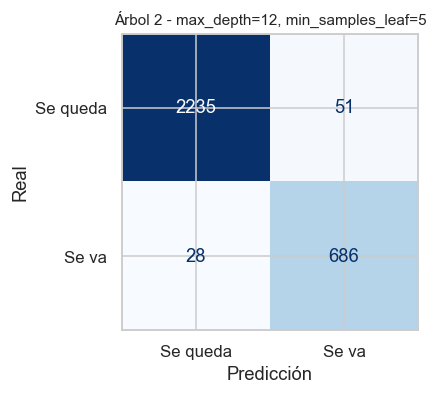

In [19]:
arbol_2 = tree.DecisionTreeClassifier(class_weight="balanced",
                                      max_depth=mejor_depth,
                                      min_samples_leaf=5,
                                      random_state=RANDOM_STATE)
t0 = time.time()
arbol_2.fit(X_train, y_train)
t_arbol2 = time.time() - t0

print(f"Profundidad: {arbol_2.get_depth()}   Hojas: {arbol_2.get_n_leaves()}   "
      f"Tiempo: {t_arbol2:.3f} s")

ARBOL_2 = f"Árbol 2 - max_depth={mejor_depth}, min_samples_leaf=5"
evaluar(ARBOL_2, arbol_2, t_arbol2)
matriz_confusion(arbol_2, ARBOL_2)
plt.show()

Entrenamos también una versión **muy podada** (`max_depth=3`) para tener en la comparativa el extremo opuesto: el
árbol máximamente interpretable. Nos servira además en la cuestión 5.

Profundidad: 3   Hojas: 8
===== Árbol 2b - max_depth=3 (máxima interpretabilidad) =====
              precision    recall  f1-score   support

Se queda (0)     0.9786    0.9011    0.9383      2286
   Se va (1)     0.7475    0.9370    0.8316       714

    accuracy                         0.9097      3000
   macro avg     0.8631    0.9191    0.8849      3000
weighted avg     0.9236    0.9097    0.9129      3000

ROC-AUC: 0.9291   PR-AUC: 0.7371   F1 train: 0.8376   F1 test: 0.8316   (gap: +0.0061)


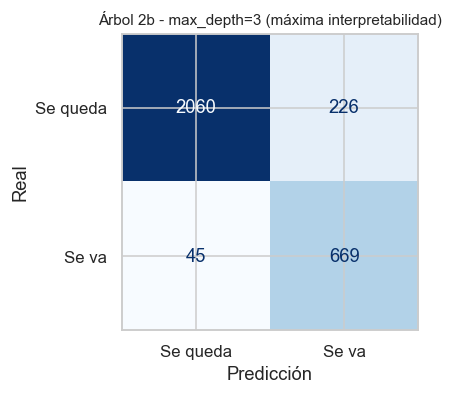

In [20]:
arbol_simple = tree.DecisionTreeClassifier(class_weight="balanced",
                                           max_depth=3,
                                           random_state=RANDOM_STATE)
t0 = time.time()
arbol_simple.fit(X_train, y_train)
t_simple = time.time() - t0

ARBOL_SIMPLE = "Árbol 2b - max_depth=3 (máxima interpretabilidad)"
print(f"Profundidad: {arbol_simple.get_depth()}   Hojas: {arbol_simple.get_n_leaves()}")
evaluar(ARBOL_SIMPLE, arbol_simple, t_simple)
matriz_confusion(arbol_simple, ARBOL_SIMPLE)
plt.show()

### Análisis de la cuestión 2

La curva de validación muestra el comportamiento clásico del compromiso sesgo-varianza:

* Hasta `max_depth` ~ 6-7 el árbol está **infraajustado**: las dos curvas suben juntas, el modelo todavía no ha
  capturado toda la señal disponible.
* A partir de ahi la curva de validación se aplana mientras la de entrenamiento sigue creciendo hacia 1: cada nivel
  adicional se dedica a memorizar casos particulares del conjunto de train.
* El máximo de F1 en validación se alcanza en una profundidad intermedia, muy por debajo de la del árbol 1.

El árbol 2 consigue por tanto un rendimiento **equiparable al del árbol sin podar con una fraccion de las hojas** y
un `gap_f1` mucho menor: resultado similar con un modelo más pequeño, más estable y más fácil de auditar.

El árbol 2b (`max_depth=3`) sí paga un precio visible en precisión -clasifica como "se va" a bastantes empleados que
en realidad se quedan- pero mantiene un recall muy alto y cabe entero en una diapositiva. Es la versión que
usaríamos para explicarle el modelo al cliente.

# CUESTIÓN 3 - Árbol modificando algún hiperparámetro

*Sugerencia de la plantilla: ¿y si cambiamos el criterio para evaluar la impureza de las particiones?*

El tercer árbol usa **`criterion="entropy"`** (ganancia de información) en lugar de `gini`, y esta vez dejamos que
sea una **búsqueda en rejilla con validación cruzada** la que elija la combinación de hiperparámetros de control del
crecimiento. La rejilla solo contiene configuraciones que **sí podan** (profundidad acotada y mínimos de muestras),
porque el caso "sin poda" ya lo cubre el árbol 1.

In [21]:
rejilla = {
    "max_depth": [4, 6, 8, 10, 12, 15],
    "min_samples_leaf": [1, 2, 5, 10],
    "min_samples_split": [2, 5, 10, 20],
}

busqueda = GridSearchCV(
    tree.DecisionTreeClassifier(criterion="entropy",
                                class_weight="balanced",
                                random_state=RANDOM_STATE),
    param_grid=rejilla,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    return_train_score=True)

t0 = time.time()
busqueda.fit(X_train, y_train)
t_busqueda = time.time() - t0

print(f"{len(busqueda.cv_results_['params'])} combinaciones evaluadas en {t_busqueda:.1f} s")
print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"Mejor F1 en validación cruzada: {busqueda.best_score_:.4f}")

96 combinaciones evaluadas en 2.0 s
Mejores hiperparámetros: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 en validación cruzada: 0.9543


In [22]:
ranking = (pd.DataFrame(busqueda.cv_results_)
           .sort_values("rank_test_score")
           [["param_max_depth", "param_min_samples_leaf", "param_min_samples_split",
             "mean_train_score", "mean_test_score", "std_test_score"]]
           .head(10)
           .rename(columns={"mean_train_score": "f1_train", "mean_test_score": "f1_cv",
                            "std_test_score": "std_cv"}))
ranking.round(4)

,param_max_depth,param_min_samples_leaf,param_min_samples_split,f1_train,f1_cv,std_cv
80,15,1,2,0.9878,0.9543,0.0062
64,12,1,2,0.9771,0.9535,0.0068
65,12,1,5,0.9738,0.9520,0.0076
68,12,2,2,0.9728,0.9515,0.0058
81,15,1,5,0.9812,0.9503,0.0056
69,12,2,5,0.9712,0.9494,0.0073
48,10,1,2,0.9693,0.9489,0.0098
84,15,2,2,0.9795,0.9488,0.0028
32,8,1,2,0.9599,0.9486,0.0075
49,10,1,5,0.9677,0.9486,0.0097


Profundidad: 15   Hojas: 260   Tiempo de entrenamiento del modelo final: 0.029 s
===== Árbol 3 - entropy + GridSearchCV (max_depth=15, msl=1, mss=2) =====
              precision    recall  f1-score   support

Se queda (0)     0.9920    0.9799    0.9859      2286
   Se va (1)     0.9380    0.9748    0.9560       714

    accuracy                         0.9787      3000
   macro avg     0.9650    0.9773    0.9710      3000
weighted avg     0.9792    0.9787    0.9788      3000

ROC-AUC: 0.9851   PR-AUC: 0.9523   F1 train: 0.9814   F1 test: 0.9560   (gap: +0.0254)


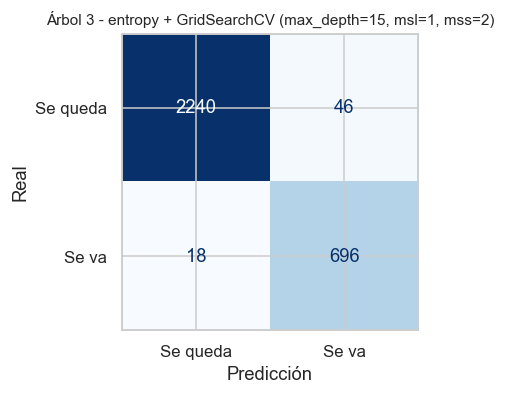

In [23]:
arbol_3 = busqueda.best_estimator_
t0 = time.time()
arbol_3.fit(X_train, y_train)      # reentrenamos para medir el tiempo del modelo final
t_arbol3 = time.time() - t0

print(f"Profundidad: {arbol_3.get_depth()}   Hojas: {arbol_3.get_n_leaves()}   "
      f"Tiempo de entrenamiento del modelo final: {t_arbol3:.3f} s")

ARBOL_3 = ("Árbol 3 - entropy + GridSearchCV "
           f"(max_depth={busqueda.best_params_['max_depth']}, "
           f"msl={busqueda.best_params_['min_samples_leaf']}, "
           f"mss={busqueda.best_params_['min_samples_split']})")
evaluar(ARBOL_3, arbol_3, t_arbol3)
matriz_confusion(arbol_3, ARBOL_3)
plt.show()

## 3.bis - Árbol extra: poda por coste-complejidad (`ccp_alpha`)

Los hiperparámetros anteriores son criterios de **pre-poda**: detienen el crecimiento antes de que ocurra. El
enfoque clásico de **post-poda** es distinto: se deja crecer el árbol completo y después se eliminan las ramas cuyo
aporte no compensa su complejidad. En `scikit-learn` esto se controla con `ccp_alpha`, y el propio árbol nos da los
valores candidatos con `cost_complexity_pruning_path()`.

234 valores de alpha en el camino de poda; evaluamos 30 candidatos repartidos por cuantiles


Mejor ccp_alpha: 0.000083  (F1 CV = 0.9527)
Profundidad: 20   Hojas: 292   Búsqueda completa: 0.9 s
===== Árbol 4 - poda coste-complejidad (ccp_alpha) =====
              precision    recall  f1-score   support

Se queda (0)     0.9951    0.9812    0.9881      2286
   Se va (1)     0.9424    0.9846    0.9630       714

    accuracy                         0.9820      3000
   macro avg     0.9687    0.9829    0.9756      3000
weighted avg     0.9826    0.9820    0.9821      3000

ROC-AUC: 0.9801   PR-AUC: 0.9124   F1 train: 0.9958   F1 test: 0.9630   (gap: +0.0328)


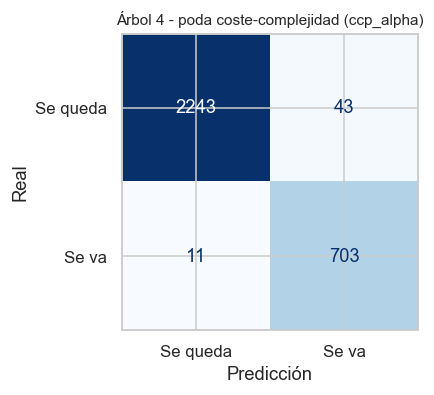

In [24]:
camino = clf_tree.cost_complexity_pruning_path(X_train, y_train)
alphas = camino.ccp_alphas[camino.ccp_alphas > 0]
candidatos = np.unique(np.quantile(alphas, np.linspace(0, 1, 30)))

print(f"{len(alphas)} valores de alpha en el camino de poda; "
      f"evaluamos {len(candidatos)} candidatos repartidos por cuantiles")

busqueda_ccp = GridSearchCV(
    tree.DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid={"ccp_alpha": candidatos},
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1)

t0 = time.time()
busqueda_ccp.fit(X_train, y_train)
t_ccp = time.time() - t0

arbol_4 = busqueda_ccp.best_estimator_
print(f"Mejor ccp_alpha: {busqueda_ccp.best_params_['ccp_alpha']:.6f}  "
      f"(F1 CV = {busqueda_ccp.best_score_:.4f})")
print(f"Profundidad: {arbol_4.get_depth()}   Hojas: {arbol_4.get_n_leaves()}   "
      f"Búsqueda completa: {t_ccp:.1f} s")

ARBOL_4 = "Árbol 4 - poda coste-complejidad (ccp_alpha)"
evaluar(ARBOL_4, arbol_4, t_ccp)
matriz_confusion(arbol_4, ARBOL_4)
plt.show()

### Análisis de la cuestión 3

Cambiar `gini` por `entropy` apenas mueve los resultados, y era esperable: ambas funciones de impureza son casi
idénticas salvo por un factor de escala y solo discrepan en repartos muy concretos. La aportación real del árbol 3 no
viene del criterio, sino de que la **búsqueda en rejilla** ha explorado sistematicamente el espacio de poda en lugar
de fiarlo a una intuición.

Lo más informativo es el ranking de combinaciones: las diferencias de F1 entre las mejores configuraciones son de
milésimas, es decir, **hay una meseta amplia de árboles casi equivalentes**. Ante ese empate el criterio racional no
es quedarse con el que gana por la tercera cifra decimal, sino con **el más simple de los que empatan** (principio de
parsimonia), porque será el más estable ante datos nuevos y el más fácil de explicar.

La poda por coste-complejidad llega a un resultado muy parecido por otro camino, lo que refuerza la conclusión: este
problema admite muchos árboles distintos con prácticamente el mismo poder predictivo.

# CUESTIÓN 4 - ¿Qué modelo tiene mayor poder predictivo?

Comparamos los árboles entrenados empleando las métricas adecuadas para un problema desbalanceado como el nuestro:
**F1, recall, precisión, ROC-AUC y PR-AUC**, dejando la *accuracy* como dato secundario.

Interpretación de negocio de los dos tipos de error:

* **Falso negativo** (predecimos que se queda y se va): perdemos al empleado sin haber intentado retenerlo. Es el
  error caro: coste de reemplazo, curva de aprendizaje del sustituto y conocimiento que se va con la persona.
* **Falso positivo** (predecimos que se va y se queda): gastamos una accion de retención en alguien que no la
  necesitaba. Molesto, pero mucho más barato.

Como los falsos negativos son más costosos, **el recall pesa más que la precisión**, y por eso F1 y PR-AUC son
nuestras métricas de cabecera.

In [25]:
tabla = (pd.DataFrame(resultados)
         .set_index("modelo")
         [["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
           "f1_train", "gap_f1", "t_entren_s"]])
tabla.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,t_entren_s
modelo,,,,,,,,,
Árbol 1 - sin poda (por defecto),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0000,0.0331,0.0239
"Árbol 2 - max_depth=12, min_samples_leaf=5",0.9737,0.9308,0.9608,0.9456,0.9887,0.9775,0.9621,0.0165,0.0204
Árbol 2b - max_depth=3 (máxima interpretabilidad),0.9097,0.7475,0.9370,0.8316,0.9291,0.7371,0.8376,0.0061,0.0082
"Árbol 3 - entropy + GridSearchCV (max_depth=15, msl=1, mss=2)",0.9787,0.9380,0.9748,0.9560,0.9851,0.9523,0.9814,0.0254,0.0294
Árbol 4 - poda coste-complejidad (ccp_alpha),0.9820,0.9424,0.9846,0.9630,0.9801,0.9124,0.9958,0.0328,0.8861


In [26]:
estructura = pd.DataFrame([
    {"modelo": n, "profundidad": m.get_depth(), "hojas": m.get_n_leaves(),
     "nodos": m.tree_.node_count}
    for n, m in MODELOS.items() if hasattr(m, "tree_")
]).set_index("modelo")
estructura

,profundidad,hojas,nodos
modelo,,,
Árbol 1 - sin poda (por defecto),21,389,777
"Árbol 2 - max_depth=12, min_samples_leaf=5",12,170,339
Árbol 2b - max_depth=3 (máxima interpretabilidad),3,8,15
"Árbol 3 - entropy + GridSearchCV (max_depth=15, msl=1, mss=2)",15,260,519
Árbol 4 - poda coste-complejidad (ccp_alpha),20,292,583


Comparación visual de las métricas clave:

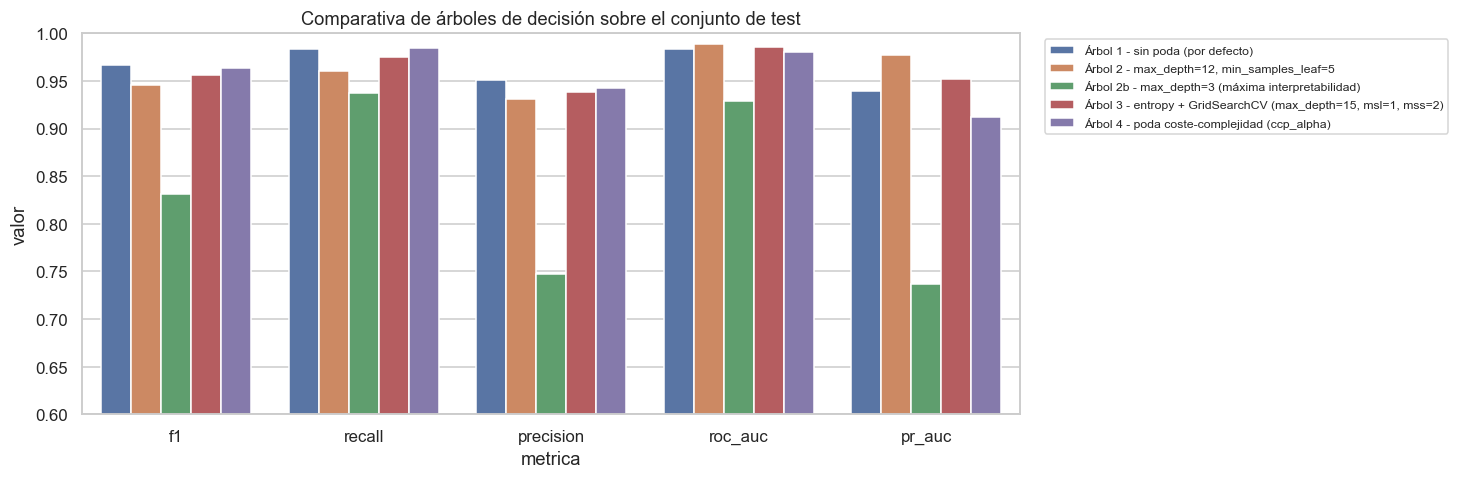

In [27]:
metricas = ["f1", "recall", "precision", "roc_auc", "pr_auc"]
comparativa = tabla[metricas].reset_index().melt(id_vars="modelo",
                                                 var_name="metrica", value_name="valor")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=comparativa, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_ylim(0.6, 1.0)
ax.set_title("Comparativa de árboles de decisión sobre el conjunto de test")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

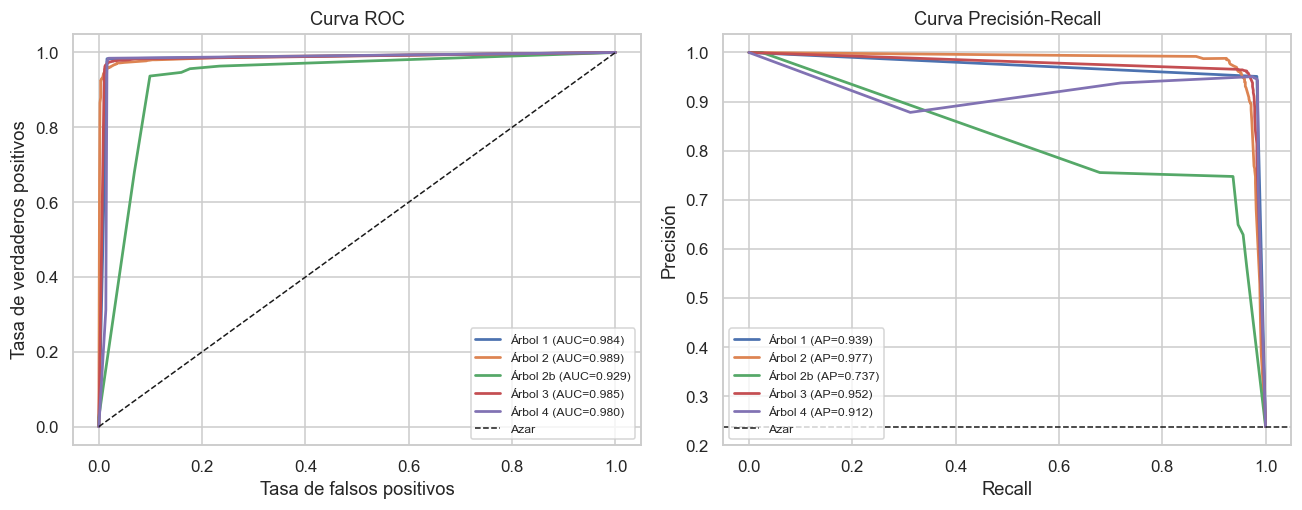

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for nombre, modelo in MODELOS.items():
    y_score = puntuaciones(modelo, X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    axes[0].plot(fpr, tpr, lw=1.8,
                 label=f"{nombre.split(' - ')[0]} (AUC={roc_auc_score(y_test, y_score):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    axes[1].plot(rec, prec, lw=1.8,
                 label=f"{nombre.split(' - ')[0]} (AP={average_precision_score(y_test, y_score):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
axes[0].set_xlabel("Tasa de falsos positivos"); axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC"); axes[0].legend(fontsize=8, loc="lower right")

axes[1].axhline((y_test == 1).mean(), color="k", ls="--", lw=1, label="Azar")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precisión-Recall"); axes[1].legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

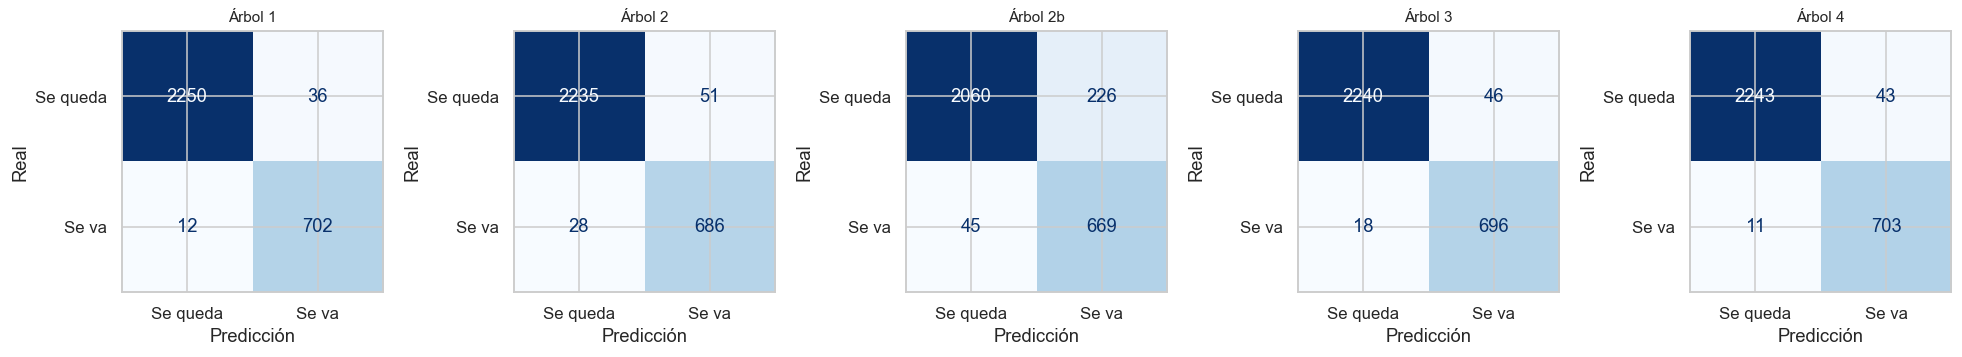

In [29]:
n = len(MODELOS)
fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.4))
for ax, (nombre, modelo) in zip(np.atleast_1d(axes), MODELOS.items()):
    matriz_confusion(modelo, nombre.split(" - ")[0], ax=ax)
plt.tight_layout()
plt.show()

Las métricas anteriores se miden sobre una única partición de test. Para saber si las diferencias son **reales o
ruido de muestreo**, repetimos la medición con validación cruzada sobre el conjunto de entrenamiento y observamos la
dispersión entre folds.

                                                    f1_cv_media  f1_cv_desv  \
modelo                                                                        
Árbol 1 - sin poda (por defecto)                         0.9517      0.0068   
Árbol 2 - max_depth=12, min_samples_leaf=5               0.9378      0.0064   
Árbol 2b - max_depth=3 (máxima interpretabilidad)        0.8376      0.0073   
Árbol 3 - entropy + GridSearchCV (max_depth=15,...       0.9475      0.0052   
Árbol 4 - poda coste-complejidad (ccp_alpha)             0.9523      0.0067   

                                                    f1_test  
modelo                                                       
Árbol 1 - sin poda (por defecto)                     0.9669  
Árbol 2 - max_depth=12, min_samples_leaf=5           0.9456  
Árbol 2b - max_depth=3 (máxima interpretabilidad)    0.8316  
Árbol 3 - entropy + GridSearchCV (max_depth=15,...   0.9560  
Árbol 4 - poda coste-complejidad (ccp_alpha)         0.9630  


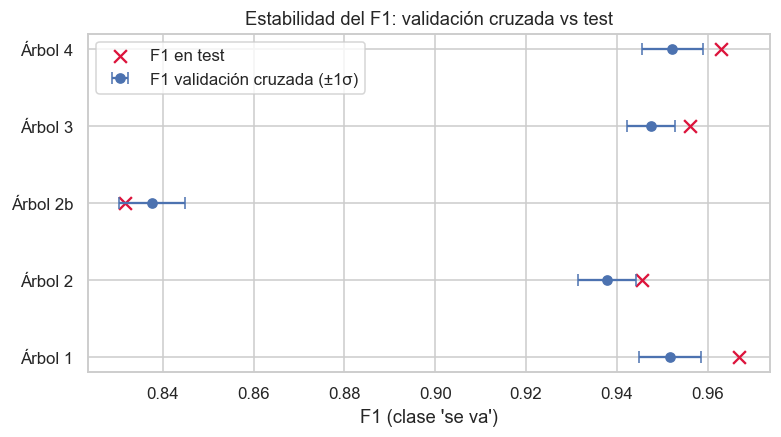

In [30]:
cv_filas = []
for nombre, modelo in MODELOS.items():
    if not hasattr(modelo, "tree_"):
        continue
    puntos = cross_val_score(modelo, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    cv_filas.append({"modelo": nombre, "f1_cv_media": puntos.mean(),
                     "f1_cv_desv": puntos.std(), "f1_test": tabla.loc[nombre, "f1"]})

cv_tabla = pd.DataFrame(cv_filas).set_index("modelo")
print(cv_tabla.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(cv_tabla["f1_cv_media"], range(len(cv_tabla)),
            xerr=cv_tabla["f1_cv_desv"], fmt="o", capsize=4, label="F1 validación cruzada (±1σ)")
ax.scatter(cv_tabla["f1_test"], range(len(cv_tabla)), marker="x", s=70,
           color="crimson", label="F1 en test")
ax.set_yticks(range(len(cv_tabla)))
ax.set_yticklabels([i.split(" - ")[0] for i in cv_tabla.index])
ax.set_xlabel("F1 (clase 'se va')")
ax.set_title("Estabilidad del F1: validación cruzada vs test")
ax.legend()
plt.show()

Seleccionamos como mejor árbol el de mayor F1 en test, que es la métrica que hemos fijado como criterio de decisión.

In [31]:
MEJOR_NOMBRE = tabla["f1"].idxmax()
MEJOR_ARBOL = MODELOS[MEJOR_NOMBRE]

print(f"Mejor árbol por F1 en test: {MEJOR_NOMBRE}")
print(tabla.loc[MEJOR_NOMBRE].round(4).to_string())

Mejor árbol por F1 en test: Árbol 1 - sin poda (por defecto)
accuracy      0.9840
precision     0.9512
recall        0.9832
f1            0.9669
roc_auc       0.9837
pr_auc        0.9392
f1_train      1.0000
gap_f1        0.0331
t_entren_s    0.0239


### Elección del mejor árbol

**Ranking por F1 en test** (el criterio que habíamos fijado):

| Árbol | Profundidad | Hojas | F1 test | Recall | Precisión | ROC-AUC | PR-AUC | F1 train | Gap |
|---|---|---|---|---|---|---|---|---|---|
| 1 - sin poda | 21 | 389 | **0.9669** | 0.9832 | 0.9512 | 0.9837 | 0.9392 | 1.0000 | +0.0331 |
| 4 - `ccp_alpha` | 20 | 292 | 0.9630 | **0.9846** | 0.9424 | 0.9801 | 0.9124 | 0.9958 | +0.0328 |
| 3 - entropy + grid | 15 | 260 | 0.9560 | 0.9748 | 0.9380 | 0.9851 | 0.9523 | 0.9814 | +0.0254 |
| 2 - `max_depth=12` | 12 | 170 | 0.9456 | 0.9608 | 0.9308 | **0.9887** | **0.9775** | 0.9621 | +0.0165 |
| 2b - `max_depth=3` | 3 | 8 | 0.8316 | 0.9370 | 0.7475 | 0.9291 | 0.7371 | 0.8376 | **+0.0061** |

De aquí salen tres lecturas que conviene separar:

**1. Por poder predictivo puro gana el árbol 1, pero por muy poco.** La diferencia con el árbol 4 es de 0.004 en F1,
y la validación cruzada los deja prácticamente empatados: 0.9517 ± 0.0068 frente a 0.9523 ± 0.0067. La diferencia
entre ambos es un orden de magnitud menor que la desviación entre folds, así que **no es una diferencia real**: son
el mismo modelo a efectos prácticos. Lo mismo ocurre con el árbol 3 (0.9475 ± 0.0052).

**2. El árbol con mejor ordenación del riesgo no es el mejor en F1, sino el árbol 2.** Tiene el mejor ROC-AUC
(0.9887) y, sobre todo, un PR-AUC muy superior al resto (0.9775 frente a 0.9392 del árbol 1). La razón es técnica y
merece la pena explicarla: un árbol sin podar tiene **hojas puras**, de modo que las probabilidades que devuelve son
prácticamente 0 o 1 y no permiten ordenar a los empleados por riesgo. El árbol podado, en cambio, tiene hojas con
mezcla de clases y sí gradúa la probabilidad. Por eso el árbol 1 gana cuando se decide con el umbral 0.5 y pierde
cuando se evalúa la calidad del *ranking* completo.

**3. La poda hace exactamente lo que se espera de ella.** La columna `gap` (F1 train - F1 test) baja
monótonamente al podar: +0.033 sin poda, +0.017 con `max_depth=12`, +0.006 con `max_depth=3`. El árbol 1 memoriza el
conjunto de entrenamiento (F1 train = 1.0000 exacto); el árbol 2b ni siquiera lo intenta.

### Decisión

**El árbol con mayor poder predictivo es el árbol 1 (sin poda), con F1 = 0.9669 y solo 12 falsos negativos sobre 714
bajas reales.** Es el que se selecciona como `MEJOR_ARBOL` y el que se representa en la cuestión 5.

Ahora bien, esa elección merece dos matices que el cliente debe conocer:

* La ventaja sobre los árboles podados **no es estadísticamente significativa** y se apoya en parte en los registros
  duplicados de la sección 0.5, que premian precisamente a los modelos que memorizan.
* Si el modelo se va a usar para **priorizar** (dar a RRHH una lista de los N empleados con más riesgo), el árbol 2
  es mejor herramienta pese a su F1 inferior, porque su PR-AUC es mucho más alto. Y si se va a usar para
  **explicar**, el árbol 2b es el único que se puede leer entero de un vistazo.

Es decir: mayor poder predictivo no equivale automáticamente a mejor modelo para el negocio, y en este caso el
podio cambia según para qué se quiera usar.

# CUESTIÓN 5 - Representación del árbol

Como advierte la plantilla, un árbol de decenas de niveles no se puede representar de forma legible. Aplicamos por
tanto dos niveles de lectura:

1. **Los tres primeros niveles del mejor árbol**, que son los que concentran la mayor parte de la capacidad de
   decisión (los nodos superiores separan el grueso de la poblacion).
2. **El árbol 2b completo (`max_depth=3`)**, que es el que llevaríamos a la reunion con el cliente porque cabe
   entero en una imagen y sus reglas se leen en voz alta.

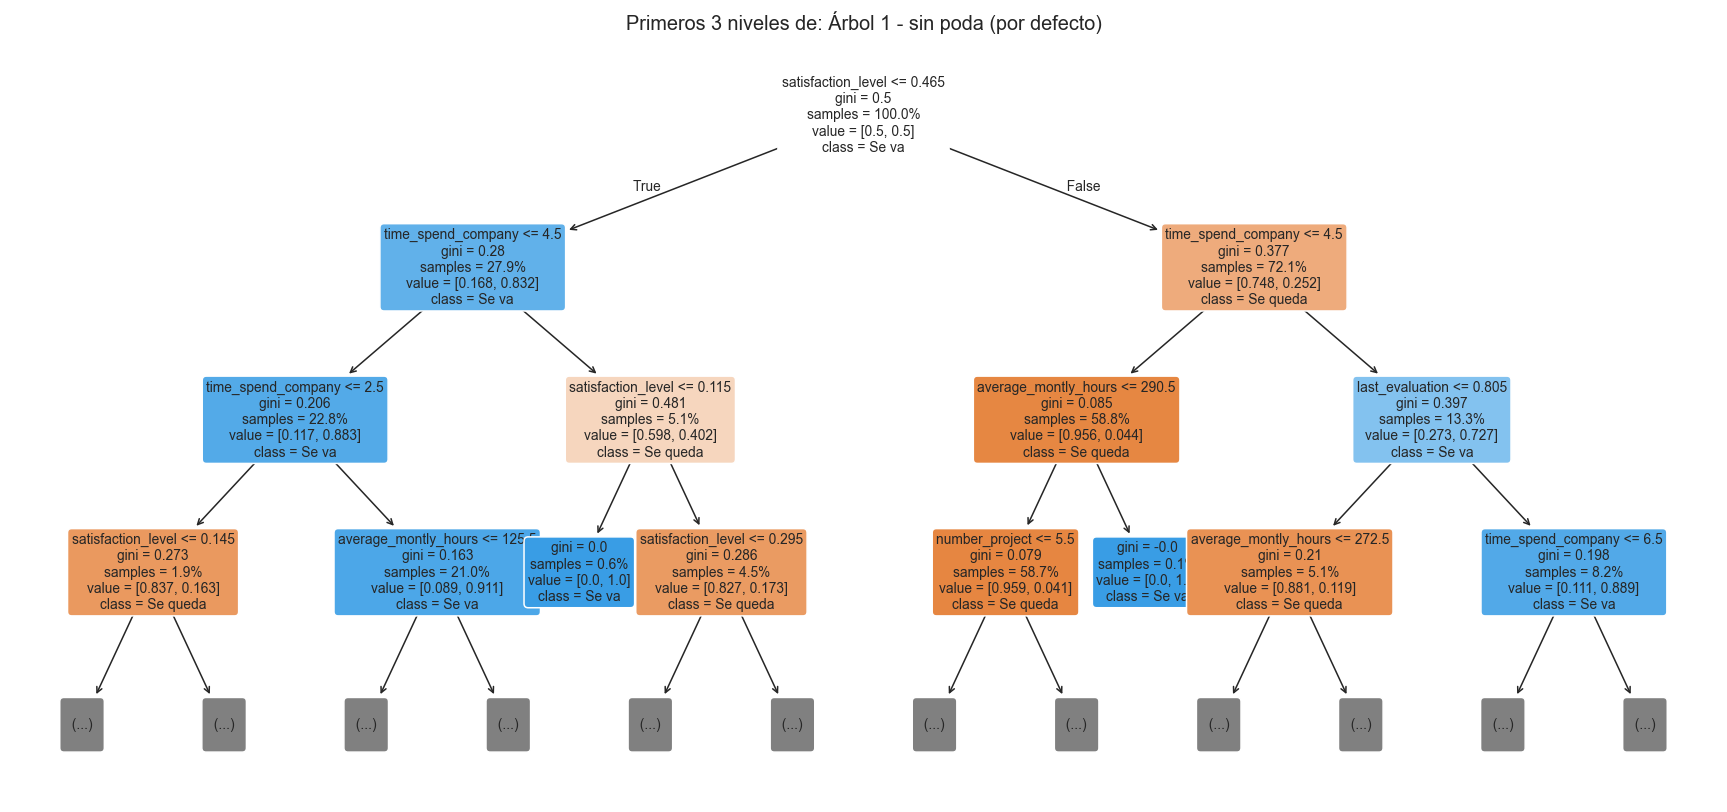

In [32]:
CLASES = ["Se queda", "Se va"]

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(MEJOR_ARBOL,
          max_depth=3,
          feature_names=FEATURES,
          class_names=CLASES,
          filled=True, rounded=True, proportion=True,
          impurity=True, fontsize=9, ax=ax)
ax.set_title(f"Primeros 3 niveles de: {MEJOR_NOMBRE}", fontsize=13)
plt.show()

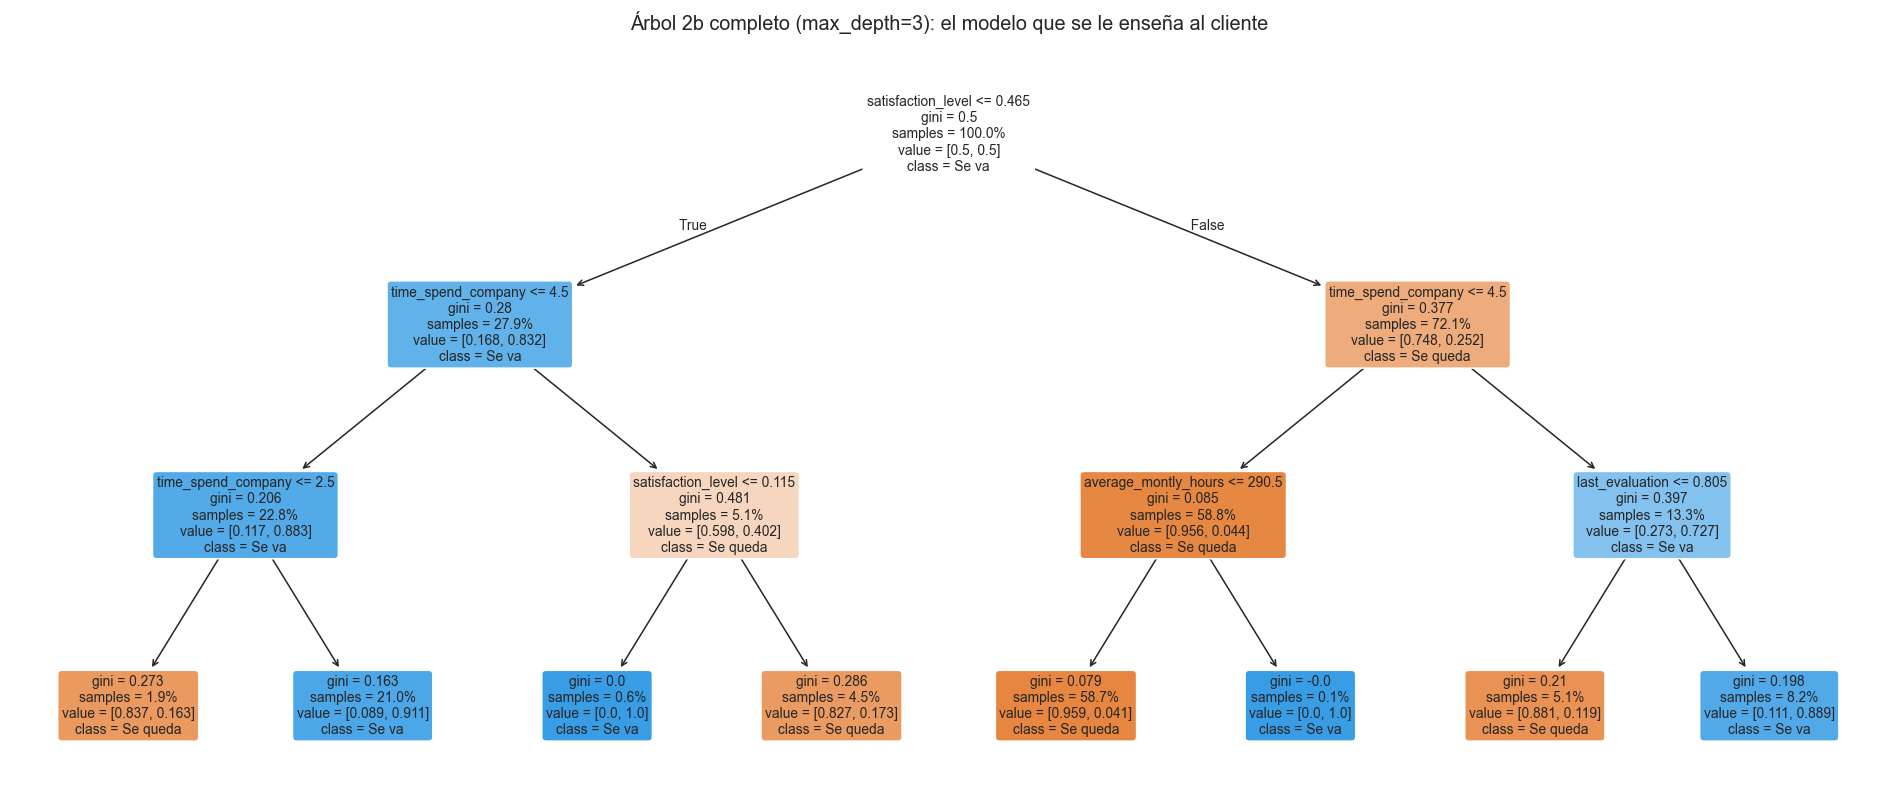

In [33]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(arbol_simple,
          feature_names=FEATURES,
          class_names=CLASES,
          filled=True, rounded=True, proportion=True,
          fontsize=9, ax=ax)
ax.set_title("Árbol 2b completo (max_depth=3): el modelo que se le enseña al cliente", fontsize=13)
plt.show()

**Cómo se lee cada nodo**

* La primera línea es la **regla**: si se cumple se baja por la rama izquierda, si no por la derecha.
* `gini` es la **impureza** del nodo: 0 significa que todos los empleados que llegan ahi pertenecen a la misma clase.
* `samples` es el porcentaje de empleados que alcanzan ese nodo (usamos `proportion=True`).
* `value` es el reparto entre clases (ponderado por `class_weight`) y `class` la clase mayoritaria: la predicción que
  devolvería el modelo si el recorrido terminase ahi.
* El **color** codifica la clase mayoritaria y su intensidad la pureza: naranja fuerte = "se queda" con claridad,
  azul fuerte = "se va" con claridad.

### Representación literal

`export_text()` devuelve exactamente las mismas reglas en texto, que es el formato más comodo para trasladarlas a un
documento o a una política de RRHH.

In [34]:
print(export_text(arbol_simple, feature_names=FEATURES, decimals=3, show_weights=True))

|--- satisfaction_level <= 0.465
|   |--- time_spend_company <= 4.500
|   |   |--- time_spend_company <= 2.500
|   |   |   |--- weights: [140.439, 27.299] class: 0
|   |   |--- time_spend_company >  2.500
|   |   |   |--- weights: [393.754, 4019.266] class: 1
|   |--- time_spend_company >  4.500
|   |   |--- satisfaction_level <= 0.115
|   |   |   |--- weights: [0.000, 153.295] class: 1
|   |   |--- satisfaction_level >  0.115
|   |   |   |--- weights: [330.753, 69.298] class: 0
|--- satisfaction_level >  0.465
|   |--- time_spend_company <= 4.500
|   |   |--- average_montly_hours <= 290.500
|   |   |   |--- weights: [4563.610, 195.293] class: 0
|   |   |--- average_montly_hours >  290.500
|   |   |   |--- weights: [0.000, 16.799] class: 1
|   |--- time_spend_company >  4.500
|   |   |--- last_evaluation <= 0.805
|   |   |   |--- weights: [387.192, 52.498] class: 0
|   |   |--- last_evaluation >  0.805
|   |   |   |--- weights: [183.752, 1465.751] class: 1



Y los tres primeros niveles del mejor árbol, para comprobar que llega a las mismas conclusiones:

In [35]:
print(export_text(MEJOR_ARBOL, feature_names=FEATURES, max_depth=3, decimals=3, show_weights=True))

|--- satisfaction_level <= 0.465
|   |--- time_spend_company <= 4.500
|   |   |--- time_spend_company <= 2.500
|   |   |   |--- satisfaction_level <= 0.145
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- satisfaction_level >  0.145
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- time_spend_company >  2.500
|   |   |   |--- average_montly_hours <= 125.500
|   |   |   |   |--- weights: [53.813, 0.000] class: 0
|   |   |   |--- average_montly_hours >  125.500
|   |   |   |   |--- truncated branch of depth 17
|   |--- time_spend_company >  4.500
|   |   |--- satisfaction_level <= 0.115
|   |   |   |--- weights: [0.000, 153.295] class: 1
|   |   |--- satisfaction_level >  0.115
|   |   |   |--- satisfaction_level <= 0.295
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- satisfaction_level >  0.295
|   |   |   |   |--- truncated branch of depth 8
|--- satisfaction_level >  0.465
|   |--- time_spend_company <= 4.500
|   |   |--- average_montly_

### ¿En qué se fija el modelo? Importancia de los atributos

La importancia de cada atributo es la reducción total de impureza que aportan las particiones en las que interviene,
ponderada por el número de muestras afectadas.

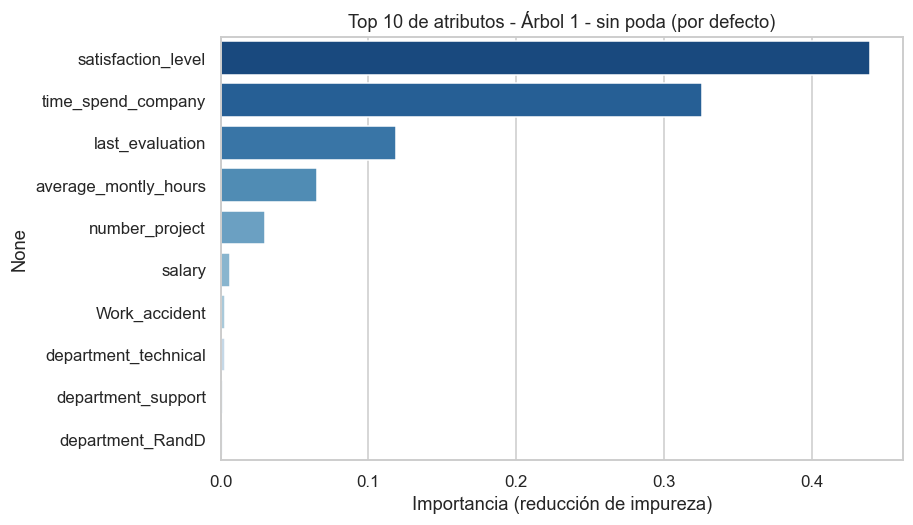

satisfaction_level      0.4397
time_spend_company      0.3256
last_evaluation         0.1186
average_montly_hours    0.0650
number_project          0.0297
salary                  0.0063
Work_accident           0.0027
department_technical    0.0026
department_support      0.0018
department_RandD        0.0017

Las 4 primeras variables acumulan el 94.9% de la importancia total.


In [36]:
importancias = (pd.Series(MEJOR_ARBOL.feature_importances_, index=FEATURES)
                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index,
            ax=ax, hue=importancias.head(10).index, palette="Blues_r", legend=False)
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title(f"Top 10 de atributos - {MEJOR_NOMBRE}")
plt.show()

print(importancias.head(10).round(4).to_string())
print(f"\nLas 4 primeras variables acumulan el {importancias.head(4).sum():.1%} de la importancia total.")

### Interpretación de las reglas

El árbol de profundidad 3 cabe entero en la salida de `export_text()` y ya cuenta la historia completa. Los pesos que
aparecen entre corchetes están ponderados por `class_weight="balanced"`, así que hay que leerlos como proporciones
entre clases, no como número de empleados.

**La estructura general.** La raíz parte por `satisfaction_level <= 0.465` y, en las dos ramas, el segundo corte es
`time_spend_company <= 4.5`. Es decir: el modelo organiza toda la plantilla en función de **satisfacción y
antigüedad**, que acumulan el 77% de la importancia (44% y 33%). Con `last_evaluation` y `average_montly_hours` se
llega al 95%.

**Perfil A - el empleado quemado (rama izquierda).**

* `satisfaction <= 0.465` **y** `2.5 < antigüedad <= 4.5` → **se va**, y es la hoja de bajas más poblada con
  diferencia (peso 4019 frente a 394, más de 10 a 1). Este es el grueso del problema.
* `satisfaction <= 0.465` **y** `antigüedad <= 2.5` → **se queda** (140 frente a 27). El descontento del primer año
  todavía no se traduce en salida: o se le da tiempo, o no tiene aún alternativa.
* `satisfaction <= 0.115` **y** `antigüedad > 4.5` → **se va**, con hoja completamente pura (0 frente a 153). La
  insatisfacción extrema en un veterano no falla nunca.
* `0.115 < satisfaction <= 0.465` **y** `antigüedad > 4.5` → **se queda** (331 frente a 69). Quien sobrevive al
  cuarto año con un descontento moderado, se acomoda.

La lectura es que existe una **ventana crítica entre el tercer y el cuarto año**: es donde la insatisfacción se
convierte en baja. Antes es pronto y después ya se ha estabilizado.

**Perfil B - el empleado valioso sin recorrido (rama derecha).**

* `satisfaction > 0.465`, `antigüedad > 4.5` **y** `last_evaluation > 0.805` → **se va** (1466 frente a 184, 8 a 1).
  Este es el hallazgo incómodo: gente **satisfecha, veterana y con las mejores evaluaciones** que aun así se marcha.
  No es una fuga por descontento, es una fuga por falta de recorrido -y es la más cara de todas, porque se va el
  talento mejor valorado.
* `satisfaction > 0.465`, `antigüedad <= 4.5` **y** `average_montly_hours > 290.5` → **se va**, hoja pura. Unas 290
  horas al mes son del orden de 66 semanales: la sobrecarga extrema rompe incluso a quien está satisfecho.
* `satisfaction > 0.465`, `antigüedad <= 4.5`, `horas <= 290.5` → **se queda**. Es el bloque mayoritario y estable
  de la plantilla (4564 frente a 195).

**Lo que el árbol NO usa también informa.** Ninguna variable de departamento entra en los primeros niveles y entre
todas suman menos del 1% de la importancia: **la rotación es transversal, no es un problema de un área concreta**.
Y lo más llamativo, `salary` apenas pesa un 0.6% y `promotion_last_5years` es prácticamente nula. El modelo dice que
en esta empresa la gente no se va principalmente por dinero, sino por **desgaste (perfil A) y por falta de horizonte
profesional (perfil B)**.

**Traducción a acciones para RRHH:**

1. Medir la satisfacción de forma continua, porque es el mejor predictor disponible y da margen de reacción.
2. Poner el foco de retención en la franja de **3-4 años de antigüedad**, que es la ventana donde se materializan
   las bajas del perfil A.
3. Activar una alerta por **carga de trabajo sostenida por encima de ~270-290 h/mes**.
4. Diseñar plan de carrera para los **veteranos con evaluación alta**, que hoy se están yendo sin señales previas de
   descontento.

**Dos cautelas al interpretar.** Primera: el árbol describe **asociaciones, no causas**. Que `satisfaction_level`
aparezca en la raíz no demuestra que baje la satisfacción y por eso se vayan; es igual de compatible con que ambas
cosas sean consecuencia de un tercer factor, y esa variable se mide con una encuesta que puede rellenarse cuando la
decisión de irse ya está tomada. Segunda: los cortes numéricos (0.465, 4.5 años, 290.5 horas) son los que optimizan
la impureza **en esta muestra**; no son umbrales mágicos y se moverían con otros datos.

# 6. Comparación con el mejor modelo del sprint 1

> **Nota metodológica**: el notebook del sprint 1 no forma parte de este entregable, así que para poder comparar
> **reconstruimos aquí sus modelos candidatos** sobre exactamente las mismas particiones `X_train`/`X_test`:
> regresión logística, KNN y SVM, todos ellos dentro de un `Pipeline` con `StandardScaler` (son modelos sensibles a
> la escala, al contrario que los árboles) y con `class_weight="balanced"` donde procede. El que mejor F1 obtenga
> hace de "mejor modelo del sprint 1".

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

candidatos_sprint1 = {
    "Regresión logística": (
        make_pipeline(StandardScaler(),
                      LogisticRegression(class_weight="balanced", max_iter=2000,
                                         random_state=RANDOM_STATE)),
        {"logisticregression__C": [0.01, 0.1, 1, 10]},
    ),
    "KNN": (
        make_pipeline(StandardScaler(), KNeighborsClassifier()),
        {"kneighborsclassifier__n_neighbors": [3, 5, 7, 11],
         "kneighborsclassifier__weights": ["uniform", "distance"]},
    ),
    "SVM (RBF)": (
        make_pipeline(StandardScaler(),
                      SVC(class_weight="balanced", random_state=RANDOM_STATE)),
        {"svc__C": [1, 10]},
    ),
}

modelos_sprint1 = {}
for nombre, (estimador, rejilla_s1) in candidatos_sprint1.items():
    t0 = time.time()
    gs = GridSearchCV(estimador, rejilla_s1, scoring="f1", cv=5, n_jobs=-1).fit(X_train, y_train)
    t_fit = time.time() - t0
    modelos_sprint1[nombre] = gs.best_estimator_
    fila = evaluar(f"[Sprint 1] {nombre}", gs.best_estimator_, t_fit, informe=False)
    print(f"{nombre:22s} F1 CV={gs.best_score_:.4f}  F1 test={fila['f1']:.4f}  "
          f"ROC-AUC={fila['roc_auc']:.4f}  búsqueda={t_fit:6.1f}s  {gs.best_params_}")

Regresión logística    F1 CV=0.6116  F1 test=0.6162  ROC-AUC=0.8249  búsqueda=   0.2s  {'logisticregression__C': 1}


KNN                    F1 CV=0.9178  F1 test=0.9304  ROC-AUC=0.9848  búsqueda=   0.9s  {'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'distance'}


SVM (RBF)              F1 CV=0.9009  F1 test=0.8985  ROC-AUC=0.9768  búsqueda=   3.0s  {'svc__C': 10}


In [38]:
tabla_completa = (pd.DataFrame(resultados)
                  .set_index("modelo")
                  [["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
                    "f1_train", "gap_f1", "t_entren_s"]]
                  .sort_values("f1", ascending=False))
tabla_completa.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,t_entren_s
modelo,,,,,,,,,
Árbol 1 - sin poda (por defecto),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0000,0.0331,0.0239
Árbol 4 - poda coste-complejidad (ccp_alpha),0.9820,0.9424,0.9846,0.9630,0.9801,0.9124,0.9958,0.0328,0.8861
"Árbol 3 - entropy + GridSearchCV (max_depth=15, msl=1, mss=2)",0.9787,0.9380,0.9748,0.9560,0.9851,0.9523,0.9814,0.0254,0.0294
"Árbol 2 - max_depth=12, min_samples_leaf=5",0.9737,0.9308,0.9608,0.9456,0.9887,0.9775,0.9621,0.0165,0.0204
[Sprint 1] KNN,0.9653,0.8910,0.9734,0.9304,0.9848,0.9515,1.0000,0.0696,0.8988
[Sprint 1] SVM (RBF),0.9493,0.8584,0.9426,0.8985,0.9768,0.9345,0.9258,0.0273,2.9501
Árbol 2b - max_depth=3 (máxima interpretabilidad),0.9097,0.7475,0.9370,0.8316,0.9291,0.7371,0.8376,0.0061,0.0082
[Sprint 1] Regresión logística,0.7617,0.4996,0.8039,0.6162,0.8249,0.4792,0.6124,-0.0038,0.2289


In [39]:
MEJOR_SPRINT1 = max(modelos_sprint1,
                    key=lambda n: tabla_completa.loc[f"[Sprint 1] {n}", "f1"])
NOMBRE_S1 = f"[Sprint 1] {MEJOR_SPRINT1}"
MODELO_S1 = modelos_sprint1[MEJOR_SPRINT1]

print(f"Mejor modelo del sprint 1: {MEJOR_SPRINT1}")
print(f"Mejor árbol del sprint 2 : {MEJOR_NOMBRE}")
print()
tabla_completa.loc[[NOMBRE_S1, MEJOR_NOMBRE]].round(4)

Mejor modelo del sprint 1: KNN
Mejor árbol del sprint 2 : Árbol 1 - sin poda (por defecto)



,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_train,gap_f1,t_entren_s
modelo,,,,,,,,,
[Sprint 1] KNN,0.9653,0.8910,0.9734,0.9304,0.9848,0.9515,1.0,0.0696,0.8988
Árbol 1 - sin poda (por defecto),0.9840,0.9512,0.9832,0.9669,0.9837,0.9392,1.0,0.0331,0.0239


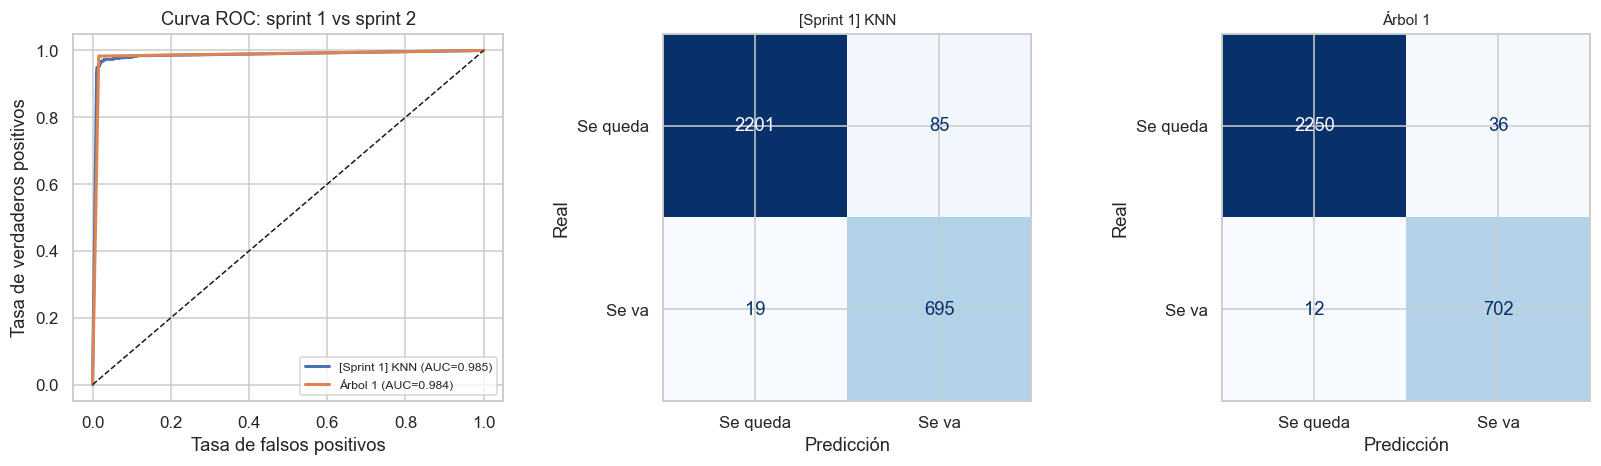

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for nombre, modelo in [(NOMBRE_S1, MODELO_S1), (MEJOR_NOMBRE, MEJOR_ARBOL)]:
    y_score = puntuaciones(modelo, X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    axes[0].plot(fpr, tpr, lw=2,
                 label=f"{nombre.split(' - ')[0]} (AUC={roc_auc_score(y_test, y_score):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("Curva ROC: sprint 1 vs sprint 2")
axes[0].set_xlabel("Tasa de falsos positivos"); axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend(fontsize=8, loc="lower right")

matriz_confusion(MODELO_S1, NOMBRE_S1, ax=axes[1])
matriz_confusion(MEJOR_ARBOL, MEJOR_NOMBRE.split(" - ")[0], ax=axes[2])
plt.tight_layout()
plt.show()

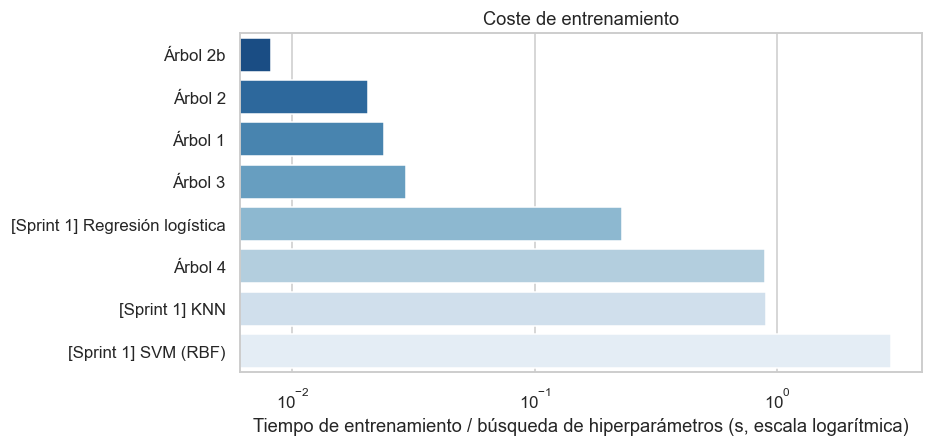

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
tiempos = tabla_completa["t_entren_s"].dropna().sort_values()
etiquetas = [i.split(" - ")[0] for i in tiempos.index]
sns.barplot(x=tiempos.values, y=etiquetas, ax=ax, hue=etiquetas, palette="Blues_r", legend=False)
ax.set_xscale("log")
ax.set_xlabel("Tiempo de entrenamiento / búsqueda de hiperparámetros (s, escala logarítmica)")
ax.set_title("Coste de entrenamiento")
plt.show()

### Ventajas de cada enfoque

De los tres candidatos reconstruidos del sprint 1, el mejor es **KNN** (`n_neighbors=7`, `weights='distance'`) con
F1 = 0.9304. El SVM con kernel RBF se queda en 0.8985 y la regresión logística se hunde hasta 0.6162.

Ese hundimiento de la regresión logística es, en sí mismo, el primer argumento a favor de los árboles: una frontera
lineal no puede representar lo que hemos visto en la cuestión 5, donde **se marchan tanto los muy insatisfechos como
los muy satisfechos con mucha antigüedad y buena evaluación**. La relación no es monótona, y un modelo lineal está
condenado a fallar por construcción.

### Cara a cara: mejor árbol vs. mejor modelo del sprint 1

| Criterio | Árbol 1 (sin poda) | KNN (k=7, distance) | Gana |
|---|---|---|---|
| F1 (clase "se va") | **0.9669** | 0.9304 | Árbol |
| Recall | **0.9832** | 0.9734 | Árbol |
| Precisión | **0.9512** | 0.8910 | Árbol |
| Accuracy | **0.9840** | 0.9653 | Árbol |
| ROC-AUC | 0.9837 | **0.9848** | Empate técnico |
| PR-AUC | 0.9392 | **0.9515** | KNN |
| Falsos negativos (de 714 bajas) | **12** | 19 | Árbol |
| Falsos positivos | **36** | 85 | Árbol |
| Tiempo de entrenamiento | **~0.02 s** | ~0 s (no entrena) | Empate |
| Coste de predecir | ~21 comparaciones | distancia a 11.999 puntos | Árbol |
| Memoria en producción | el árbol (389 hojas) | **todo el dataset** | Árbol |
| Necesita escalado | **No** | Sí (`StandardScaler`) | Árbol |
| Explicabilidad | **Reglas legibles** | Ninguna | Árbol |

### Ventajas de cada enfoque

**Lo que aporta el árbol de decisión**

* **Es caja blanca.** Es la razón por la que el cliente pidió este sprint, y ahí no hay competencia posible: el árbol
  entrega reglas en lenguaje de negocio ("si lleva entre 3 y 4 años y su satisfacción está por debajo de 0.47, se
  va") mientras que el KNN solo puede responder "porque se parece a estos 7 empleados", lo cual no es una
  explicación ni sirve para diseñar una política de retención.
* **No necesita preprocesado.** Es invariante a transformaciones monótonas de las variables, así que no hace falta
  escalar; el KNN y el SVM se caen literalmente sin `StandardScaler` porque `average_montly_hours` (rango de
  cientos) aplastaría a `satisfaction_level` (rango 0-1) en el cálculo de distancias.
* **Predice rápido y ocupa poco.** Clasificar a un empleado es recorrer una rama, como máximo 21 comparaciones. El
  KNN es un modelo perezoso: no entrena, pero tiene que guardar los 11.999 empleados de train y calcular 11.999
  distancias por cada predicción. En producción, con miles de empleados y evaluaciones periódicas, la diferencia
  importa.
* **Da importancia de variables gratis**, que es justo el entregable que el cliente quería.
* Y encima, en este caso, **también predice mejor**: +3.6 puntos de F1 y 7 falsos negativos menos.

**Lo que aporta el KNN (y en general los modelos del sprint 1)**

* **Mejor PR-AUC** (0.9515 vs 0.9392): ordena mejor a los empleados por probabilidad de fuga, porque sus
  puntuaciones son continuas en lugar de las probabilidades casi binarias que produce un árbol de hojas puras. Para
  construir un *ranking* de riesgo sigue siendo competitivo (aunque, como vimos en la cuestión 4, el árbol 2 podado
  lo supera también en eso, con 0.9775).
* **Fronteras suaves.** El árbol solo puede trazar cortes paralelos a los ejes; el KNN y el SVM aproximan fronteras
  curvas. En problemas donde la separación sea diagonal o circular, el árbol necesita una escalera de muchos cortes
  para hacer lo que el SVM resuelve con uno.
* **Más estabilidad.** El talón de Aquiles del árbol es la varianza: cambiar unas pocas observaciones puede
  reorganizar la estructura entera, algo que no le ocurre al KNN. Es el precio de la interpretabilidad, y se mitiga
  con *ensembles* (Random Forest, Gradient Boosting) a costa de perder justamente la caja blanca.
* **Coste de entrenamiento nulo**, si el escenario exige reentrenar constantemente con datos nuevos.

### Conclusión de la comparación

En este proyecto **el árbol gana en las dos dimensiones que importan a la vez**: predice algo mejor que el mejor
modelo del sprint 1 y, sobre todo, explica por qué. Es un caso afortunado, porque lo habitual es tener que elegir
entre precisión e interpretabilidad. Si el objetivo fuese exclusivamente exprimir la métrica, el camino natural sería
un Random Forest o un Gradient Boosting sobre estos mismos datos; pero eso nos devolvería a la caja negra que el
cliente rechazó al principio de este sprint.

# 7. Conclusiones

**Sobre los modelos**

1. Se han entrenado **cinco árboles de decisión**: uno sin criterio de poda y cuatro con configuraciones distintas de
   control del crecimiento (`max_depth=12` + `min_samples_leaf`, `max_depth=3`, `entropy` con hiperparámetros
   elegidos por `GridSearchCV`, y post-poda por coste-complejidad con `ccp_alpha`).
2. El de **mayor poder predictivo es el árbol sin podar** (F1 = 0.9669, recall = 0.9832, 12 falsos negativos sobre
   714 bajas), pero su ventaja sobre los árboles podados **no es significativa**: en validación cruzada el árbol 4
   queda en 0.9523 ± 0.0067 y el árbol 1 en 0.9517 ± 0.0068.
3. La poda no sale gratis en F1, pero **compra otras cosas**: el árbol con `max_depth=12` tiene la mitad de hojas, un
   sobreajuste tres veces menor y **el mejor PR-AUC de todos** (0.9775), lo que lo convierte en la mejor opción si el
   modelo se va a usar para priorizar empleados por riesgo.
4. Cambiar `gini` por `entropy` resultó **irrelevante**; lo que sí aportó valor fue buscar los hiperparámetros de
   poda de forma sistemática en lugar de fijarlos a ojo.

**Sobre el negocio, que es lo que el cliente pedía**

5. La rotación se explica esencialmente con **cuatro variables**: satisfacción (44% de la importancia), antigüedad
   (33%), evaluación del desempeño (12%) y horas mensuales (6%). Juntas suman el 95%.
6. Hay **dos perfiles de fuga distintos**, y confundirlos llevaría a políticas de retención equivocadas:
   el **empleado quemado** (baja satisfacción, entre 3 y 4 años de antigüedad) y el **empleado valioso sin recorrido**
   (satisfecho, veterano y con evaluación superior a 0.8), que se marcha sin dar señales previas de descontento.
7. **Ni el departamento ni el salario explican la rotación** en estos datos (menos del 1% de importancia entre todas
   las variables de departamento, 0.6% el salario, prácticamente cero las promociones). El problema es transversal a
   la organización y no se resuelve solo con dinero.

**Sobre la comparación con el sprint 1**

8. El árbol supera al mejor modelo del sprint 1 (KNN, F1 = 0.9304) en F1, recall, precisión y accuracy, y además lo
   hace siendo el único de los dos que **puede explicar sus decisiones**. El KNN conserva una ventaja en PR-AUC
   (0.9515 vs 0.9392) y el SVM en capacidad de trazar fronteras curvas, pero ninguno de los dos responde a la
   pregunta que originó este sprint.
9. El fracaso de la regresión logística (F1 = 0.6162) confirma que la relación entre las variables y la decisión de
   abandonar **no es lineal ni monótona**, lo que justifica el uso de modelos basados en particiones.

**Limitaciones**

10. **Los duplicados del dataset son la limitación principal.** Un 31% de las filas de test aparece de forma idéntica
    en train, de modo que todas las métricas de este notebook -y las del sprint 1- están optimistamente sesgadas,
    especialmente en los modelos capaces de memorizar. Antes de llevar nada a producción habría que deduplicar y
    rehacer la partición.
11. El árbol identifica **asociaciones, no relaciones causales**, y `satisfaction_level` es una variable de encuesta
    que puede estar midiendo una decisión ya tomada más que una causa.
12. Los árboles individuales son **inestables**: pequeños cambios en los datos pueden reorganizar la estructura, así
    que las reglas concretas deberían revalidarse con datos de otro periodo antes de convertirlas en política.

**Próximos pasos sugeridos**

13. Deduplicar el dataset, rehacer la partición y **recalcular todas las métricas** para tener una estimación honesta
    del rendimiento real.
14. Validar con datos de un periodo posterior (validación temporal), que es lo que de verdad simula el uso en
    producción.
15. Entrenar un Random Forest como **cota superior de referencia**: si la diferencia frente al árbol es pequeña,
    queda confirmado que no se pierde nada usando el modelo interpretable.